In [1]:
import numpy as np
import pickle
from matrix_processing_helpers import sparsify_global_percentile
import matplotlib.pyplot as plt

In [2]:
with open("Results/rollout_local/value_matrices3layers.pkl", "rb") as f:
    value_matrices = pickle.load(f)

with open("Results/rollout_local/attn_matrices3layers.pkl", "rb") as f:
    attn_matrices = pickle.load(f)

In [3]:
V1 = np.mean(value_matrices['layer_0'].numpy(), axis=0)
V2 = np.mean(value_matrices['layer_1'].numpy(), axis=0)
V3 = np.mean(value_matrices['layer_2'].numpy(), axis=0)

# Replace these with your three trained value matrices
# Each should have shape (d, p)
V_matrices = {
    "Layer 1": V1,
    "Layer 2": V2,
    "Layer 3": V3,
}

A1 = np.mean(attn_matrices['layer_0']['attn_matrix'], axis=0)
A2 = np.mean(attn_matrices['layer_1']['attn_matrix'], axis=0)
A3 = np.mean(attn_matrices['layer_2']['attn_matrix'], axis=0)

# Replace these with your three trained value matrices
# Each should have shape (d, p)
A_matrices = {
    "Layer 1": A1,
    "Layer 2": A2,
    "Layer 3": A3,
}

In [4]:
def value_matrix_diagnostics(V, eta=0.99, ks=(1, 2, 3, 5, 10)):
    s = np.linalg.svd(V, compute_uv=False)

    # Spectral gap analogue
    sigma_ratio = s[1] / s[0] if len(s) > 1 and s[0] > 0 else np.nan

    # Entropy effective rank
    p = s / s.sum()
    p = p[p > 0]
    effective_rank = np.exp(-np.sum(p * np.log(p)))

    # Stable rank
    stable_rank = np.sum(s**2) / s[0]**2 if s[0] > 0 else np.nan

    # Energy curve
    energy_curve = np.cumsum(s**2) / np.sum(s**2)

    # Effective number of leaders
    k_eff = np.searchsorted(energy_curve, eta) + 1

    # Energy at selected k
    energy = {
        k: energy_curve[k-1]
        for k in ks
        if k <= len(s)
    }

    return s, sigma_ratio, effective_rank, stable_rank, energy, k_eff


Layer 1
-------
Shape: (72, 16)
Top singular values: [4.5273676 4.3671103 3.9515724 3.3769605 3.0919735 2.8603077 2.8317132
 2.6213975 2.3271015 2.1231546]
sigma_2 / sigma_1: 0.9646
Entropy effective rank: 14.5956
Stable rank: 5.9697
Effective rank: 1.0000
Energy captured by first 1: 16.75%
Energy captured by first 2: 32.34%
Energy captured by first 3: 45.10%
Energy captured by first 5: 62.23%
Energy captured by first 10: 89.20%

Layer 2
-------
Shape: (72, 16)
Top singular values: [11.587378    2.4141772   0.9783594   0.8144194   0.66686124  0.58552384
  0.5533324   0.45330018  0.4306149   0.33113977]
sigma_2 / sigma_1: 0.2083
Entropy effective rank: 5.2620
Stable rank: 1.0690
Effective rank: 1.0000
Energy captured by first 1: 93.54%
Energy captured by first 2: 97.61%
Energy captured by first 3: 98.27%
Energy captured by first 5: 99.04%
Energy captured by first 10: 99.85%

Layer 3
-------
Shape: (72, 16)
Top singular values: [9.247702   1.0483797  0.77217966 0.5059158  0.31837416 0.2

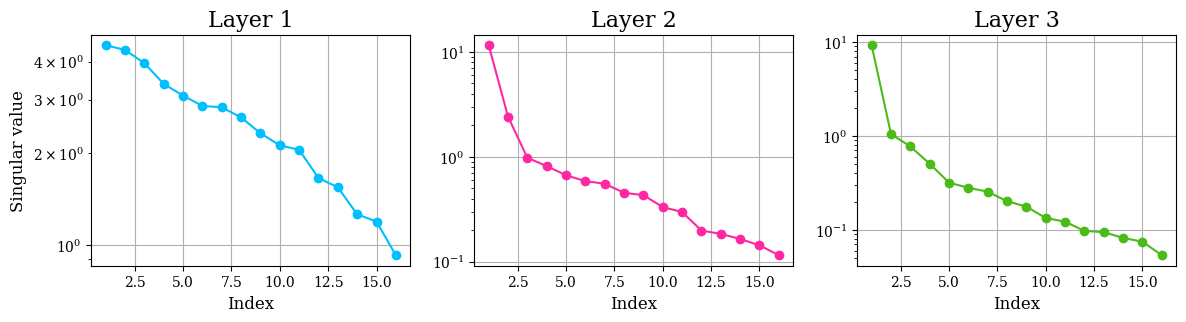

In [11]:
plt.rcParams.update({"font.family": "serif"})

n_plot = len(V_matrices)

colors = {"Layer 1": "#00BFFF",
          "Layer 2": "#FE28A2",
          "Layer 3": "#4CBB17"
         }
          

fig, axes = plt.subplots(1, n_plot, figsize=(14,3))

for i, (key, value) in enumerate(V_matrices.items()):
    
    s, ratio, r_eff, r_stable, energy, k_eff = value_matrix_diagnostics(value, eta=0.1)

    axes[i].plot(np.arange(1, len(s) + 1), s, marker="o", color=colors[key])
    axes[i].set_yscale("log")

    axes[i].set_xlabel("Index", fontsize=12)

    # axes[i].set_xticks(np.arange(1, len(s) + 1))

    if i == 0:
        axes[i].set_ylabel("Singular value", fontsize=12)
        
    axes[i].set_title(f"{key}", fontsize=16)
    axes[i].grid(True)

    print(f"\n{key}")
    print("-" * len(key))
    print(f"Shape: {value.shape}")
    print(f"Top singular values: {s[:10]}")
    print(f"sigma_2 / sigma_1: {ratio:.4f}")
    print(f"Entropy effective rank: {r_eff:.4f}")
    print(f"Stable rank: {r_stable:.4f}")
    print(f"Effective rank: {k_eff:.4f}")

    for k, val in energy.items():
        print(f"Energy captured by first {k}: {100 * val:.2f}%")


# fig.suptitle("Singular-value decay", y=1.15, fontsize=20)
plt.savefig("Results/effective_rank.pdf", bbox_inches="tight")

plt.show()